# SEMagency
## Data Science


Ce notebook constitue la phase d’idéation du cycle CRISP-ML pour un projet de prédiction du prix de vente de maisons, développé pour le compte de l’agence immobilière SEMagency.

L’objectif de cette première phase est de :

Comprendre les données disponibles sur les biens (surface, qualité, localisation…)

Identifier et corriger les éventuelles incohérences ou valeurs manquantes

Explorer les relations entre les caractéristiques d’un bien et son prix de vente

Construire un modèle de régression linéaire baseline pour produire une estimation initiale

Évaluer ce modèle à l’aide de la métrique RMSLE, adaptée aux cas de forte variabilité de prix



# 1. Compréhension de l'activité et des données

Toute application de machine learning débute par une phase de cadrage, qui consiste à définir clairement le périmètre du projet, les objectifs métier, les critères de succès, ainsi qu’à évaluer la qualité des données disponibles.
Dans notre cas, cette étape permet de valider la faisabilité du projet d’estimation des prix immobiliers pour SEMagency, et de s’assurer que les données sont exploitables pour construire un modèle prédictif fiable.

In [120]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

In [121]:
train_raw = pd.read_csv('train.csv', index_col = 'Id')
validation_raw = pd.read_csv('test.csv', index_col = 'Id')

## 1.1 Premier aperçu de l'ensemble de données


In [122]:
train_raw.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### La variable dépendante

La première étape de toute démarche de modélisation consiste à examiner la variable cible, ici SalePrice, qui représente le prix de vente final d’un bien immobilier.
Dans le cadre du projet pour SEMagency, c’est cette variable que nous cherchons à prédire à partir des caractéristiques du bien (surface, qualité, localisation, etc.).

In [123]:
# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ce n'est pas très visuel, mais nous pouvons déjà voir que le quartile inférieur se situe autour de 130 000, la médiane à 163 000, la moyenne à 180 000 et le quartile supérieur à 214 000. Cela signifie que la distribution est asymétrique.
Cela signifie que la moyenne est tirée vers le haut par des valeurs extrêmes (maisons très chères).
Ce type d’asymétrie est typique dans l’immobilier : beaucoup de biens autour du prix “standard”, et quelques biens premium très au-dessus de la moyenne.


Traçons la distribution pour voir ce qu'il en est.

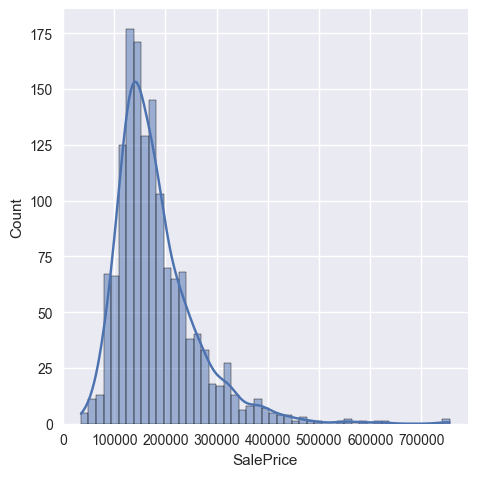

In [124]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

Nous pouvons voir que la distribution est complètement asymétrique. Effectuons un rapide test d'hypothèse pour confirmer qu'elle n'est pas normale.

Dans notre cas, l'hypothèse nulle stipule que la variable **Prix de vente** provient d'une population normalement distribuée. Nous devons effectuer le _test de Shapiro-Wilk__ afin de rejeter notre hypothèse nulle.

https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


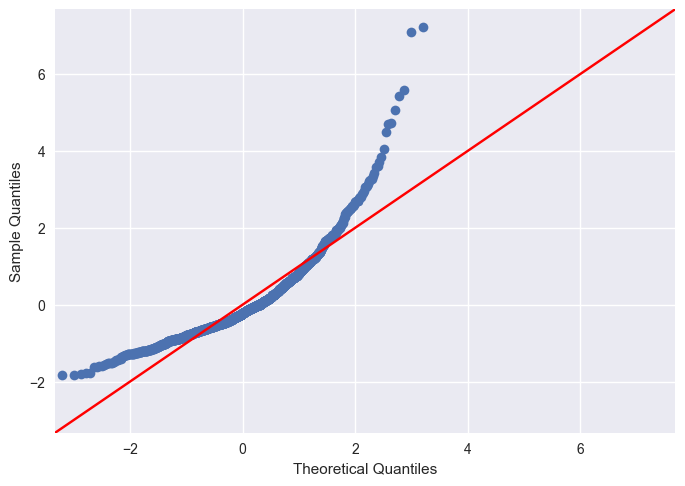

In [125]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le _test de Shapiro-Wilk__ ainsi que le **Q-Q plot** confirment que la variable ne provient pas d'une population normalement distribuée.

https://en.wikipedia.org/wiki/Q%E2%80%93Q_plot

Pour SEMagency, cette observation est importante, car elle justifie l’usage de transformations logarithmiques pour stabiliser la variance et éviter que les maisons très chères ne biaisent les prédictions.

Voyons donc à quoi ressemble un ajustement log-normal !




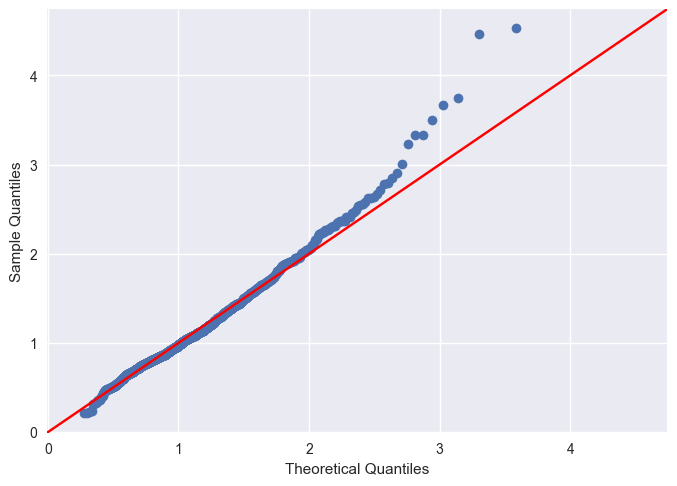

In [126]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

Ce n'est pas encore parfait. Voyez-vous ces valeurs extrêmes qui dévient en haut à droite ? Cependant, c'est déjà beaucoup mieux. Nous devrons probablement supprimer ces valeurs extrêmes, car les algorithmes de régression ne se comportent pas bien avec elles.

Transformons notre variable cible PrixVente à l'aide de la correspondance suivante

$$ x \mapsto \log(1 + x) $$

C'est exactement la fonction NumPy **log1p**. Nous écrivons le **logarithme de PrixVente** dans une variable dédiée **y**.

https://numpy.org/doc/stable/reference/generated/numpy.log1p.html




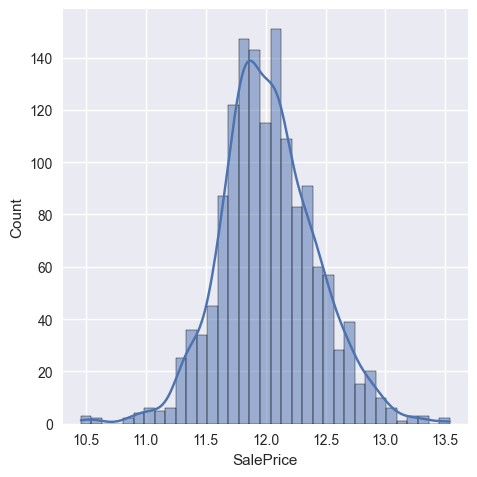

In [127]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

Ce graphique montre la distribution de la variable SalePrice après transformation logarithmique, révélant une forme quasi normale qui confirme que l’application du logarithme permet de stabiliser la variance et de rendre la cible plus adaptée à un modèle de régression.

### Les variables indépendantes

Il est maintenant temps d'analyser les variables indépendantes et leur interaction avec le **SalePrice**. Il est probable que nous devrons d'abord procéder à un nettoyage de base des données.


Dans notre ensemble de données il y'a trois types de variables :

1. Qualitatives.
2. Quantitatives,
3. Date.


Les variables **OverallQual** et **OverallCond** sont qualitatives. Cependant, nous les considérerons comme des variables quantitatives puisqu'elles sont déjà représentées par des valeurs sur une échelle ordinale.

http://jse.amstat.org/v19n3/decock/DataDocumentation.txt



In [128]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

Afin de nettoyer entièrement les données, nous concaténons les **train_raw** avec les **test_raw**. Cela permet de ne plus devoir traiter des valeurs manquantes plus tard dans le jeu de données de validation.

In [129]:
data_raw = pd.concat([train_raw, validation_raw])

## 1.2 Imputation des valeurs manquantes

Examinons d'abord les variables manquantes. La fonction suivante permet de tracer le nombre de NA par colonne.

In [130]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

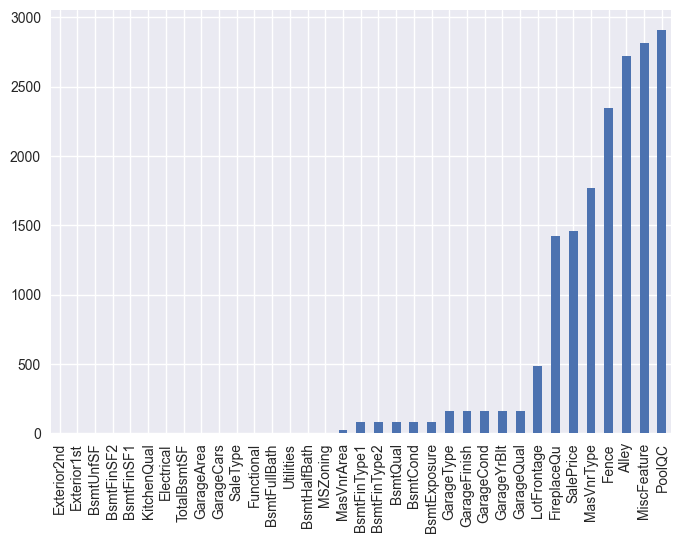

In [131]:
plot_missing(data_raw)

Au sein de SEMagency, nous avons constaté que le fichier test.csv présente davantage de valeurs manquantes que le fichier train.csv, ce qui est typique dans un contexte opérationnel. Par exemple, la variable TotalBsmtSF (surface totale du sous-sol) est entièrement renseignée dans notre historique de ventes (train.csv), mais certaines données sont absentes dans les dossiers en attente d’estimation (test.csv).

Cela reflète une réalité terrain : les biens déjà vendus ont généralement un dossier plus complet, tandis que les biens en cours d’évaluation ou récemment intégrés dans notre base peuvent comporter des zones d’ombre. En tant qu’agence, nous savons que ce type de déséquilibre est fréquent.

Pour assurer une cohérence dans le traitement des données, nous avons choisi de fusionner nos jeux train et test durant l’analyse exploratoire. Cela nous permet de détecter et gérer les valeurs manquantes de manière uniforme, et de garantir un prétraitement robuste applicable à tous les cas que nous rencontrons.






### Quantitative variables

Chez SEMagency, nous savons que lorsqu’une donnée est absente dans une variable comme GarageArea ou TotalBsmtSF, cela signifie généralement que la maison ne dispose tout simplement pas de cette caractéristique. Par exemple, une surface de garage manquante indique souvent qu’il n’y a pas de garage, et non une erreur dans le fichier. Dans ce cas, la solution la plus logique est de remplacer ces valeurs manquantes par 0.

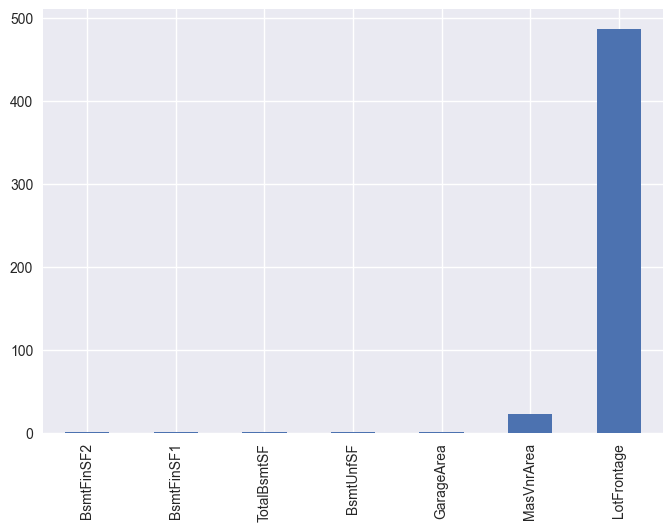

In [132]:
plot_missing(data_raw[quantitative])

In [133]:
# For quantitative variables, we will fill columns with 0
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

### Variables qualitative

Dans notre cas lorsqu'un champ est vide pour les variables qualitatives comme GarageQual ou GarageCond, cela signifie que ces propriétés ne dispose tout simplement pas de garage et non que c'est un oublie de renseignanements de valeurs. Cela se voit notamment car toutes les variables concernant le garage ont le même nombre de valeur manquantes.
La stratégie la plus judicieuse pour les variables qualitatives consiste à remplir les champs vides par la valeur "NA", afin de signaler clairement l’absence de la caractéristique

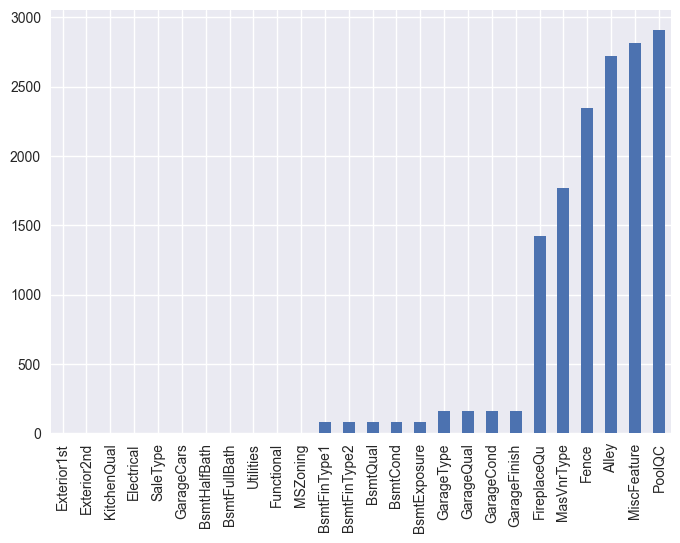

In [134]:
plot_missing(data_raw[qualitative])

Nous n'avons pas besoin de définir une fonction particulière pour cela car nous utilisons la fonction **fill_missing_with_constant** définie précédemment.

### Date variables

Dans notre cas, la seule variable de date qui a des valeurs manquantes est **GarageYrBlt**, c’est très probablement parce que le bien ne possède pas de garage. Il est donc cohérent, d’un point de vue métier, de remplacer cette valeur par YearBuilt, car lorsqu’un garage est présent, il est généralement construit en même temps que la maison.

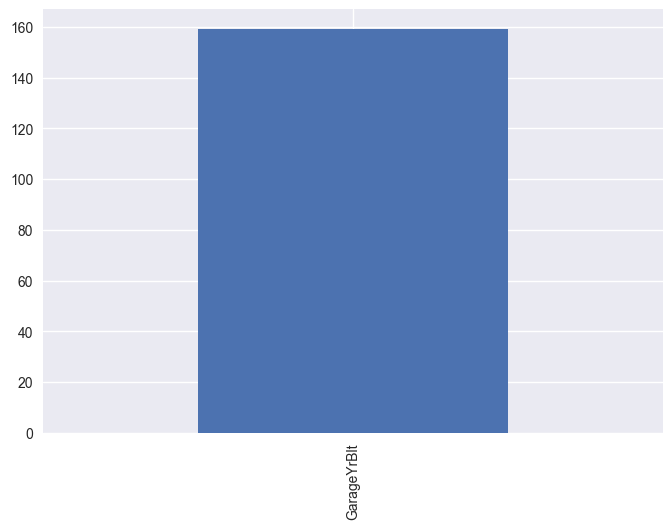

In [135]:
plot_missing(data_raw[date])

In [136]:
# For date variables, we will fill the missing values using the values from another column
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## 1.3 Transformation de base

Étant donné que les ventes s'échelonnent de 2006 à 2010, il serait logique de calculer le nombre d'années écoulées depuis que la maison a été construite, rénovée, etc. Cela permet pour notre modèle baseline de tirer une véritable information des dates qui influenceront notre variable dépendante.

In [137]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## 1.4 Exécuter le processus de nettoyage
Nous allons maintenant procéder au nettoyage de l'ensemble des données et les explorer.

In [138]:
def clean(data) :
    
    data_clean = data.copy()
    
    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

Lançons le processus de nettoyage.

In [139]:
data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


## 1.5 Compréhension exploratoire des données

Nous allons maintenant procéder à l'AED et réfléchir à la manière dont nous allons résoudre notre cas. Nous avons deux types de variables, les variables catégorielles et les variables numériques. En outre, nous devons diviser notre ensemble de données nettoyé en un ensemble de données de formation et un ensemble de données de validation, comme auparavant.

In [140]:
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

numeric = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
           'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
           'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
           'PoolArea', 'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Split of the clean dataset into train & validation
train_clean = data_clean[data_clean.index.isin(train_raw.index)]
validation_clean = data_clean[data_clean.index.isin(validation_raw.index)]

### Analyse des variables numériques

Nous allons maintenant ragarder la corrélation entre chaque variable numérique avec notre variable cible, c'est-à-dire le **logarithme de SalePrice** et non pas **SalePrice** car le lien n'est probablement pas linéaire comme nous l'avons vu précédemment.

In [141]:
def correlation(y, X, features, method = 'pearson'):
    
    cor = pd.DataFrame()
    cor['feature'] = features
    
    cor['correlation_coef'] = [X[f].corr(y, method = method) for f in features]
    cor['correlation_coef'] = cor['correlation_coef'].fillna(0)
    
    cor = cor.sort_values('correlation_coef', ascending = False)

    plt.figure(figsize=(10, 0.25*len(features)))
    sns.barplot(data = cor, y = 'feature', x = 'correlation_coef', orient = 'h')
    
    return cor

Nous regardons ensuite les corrélations entre les variables numériques et le **logarithme de SalePrice** sur l'ensemble de données train_clean.

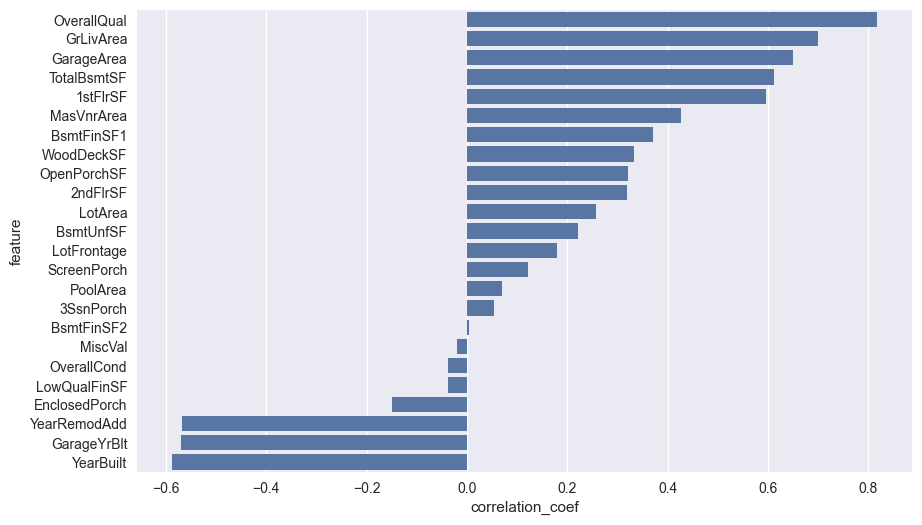

In [142]:
cor = correlation(target, train_clean, numeric, method = 'pearson')

Comme la valeur de corrélation elle-même peut être trompeuse, nous traçons des diagrammes de dispersion pour ces caractéristiques numériques. Corrélation ne signifie pas causalité

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def scatter_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        x = X[f]
        sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
        axes[i].set_title(f'Corrélation : {f} vs {y.name}')

    # Supprimer les cases vides si le nombre de variables n'est pas un multiple de cols
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()


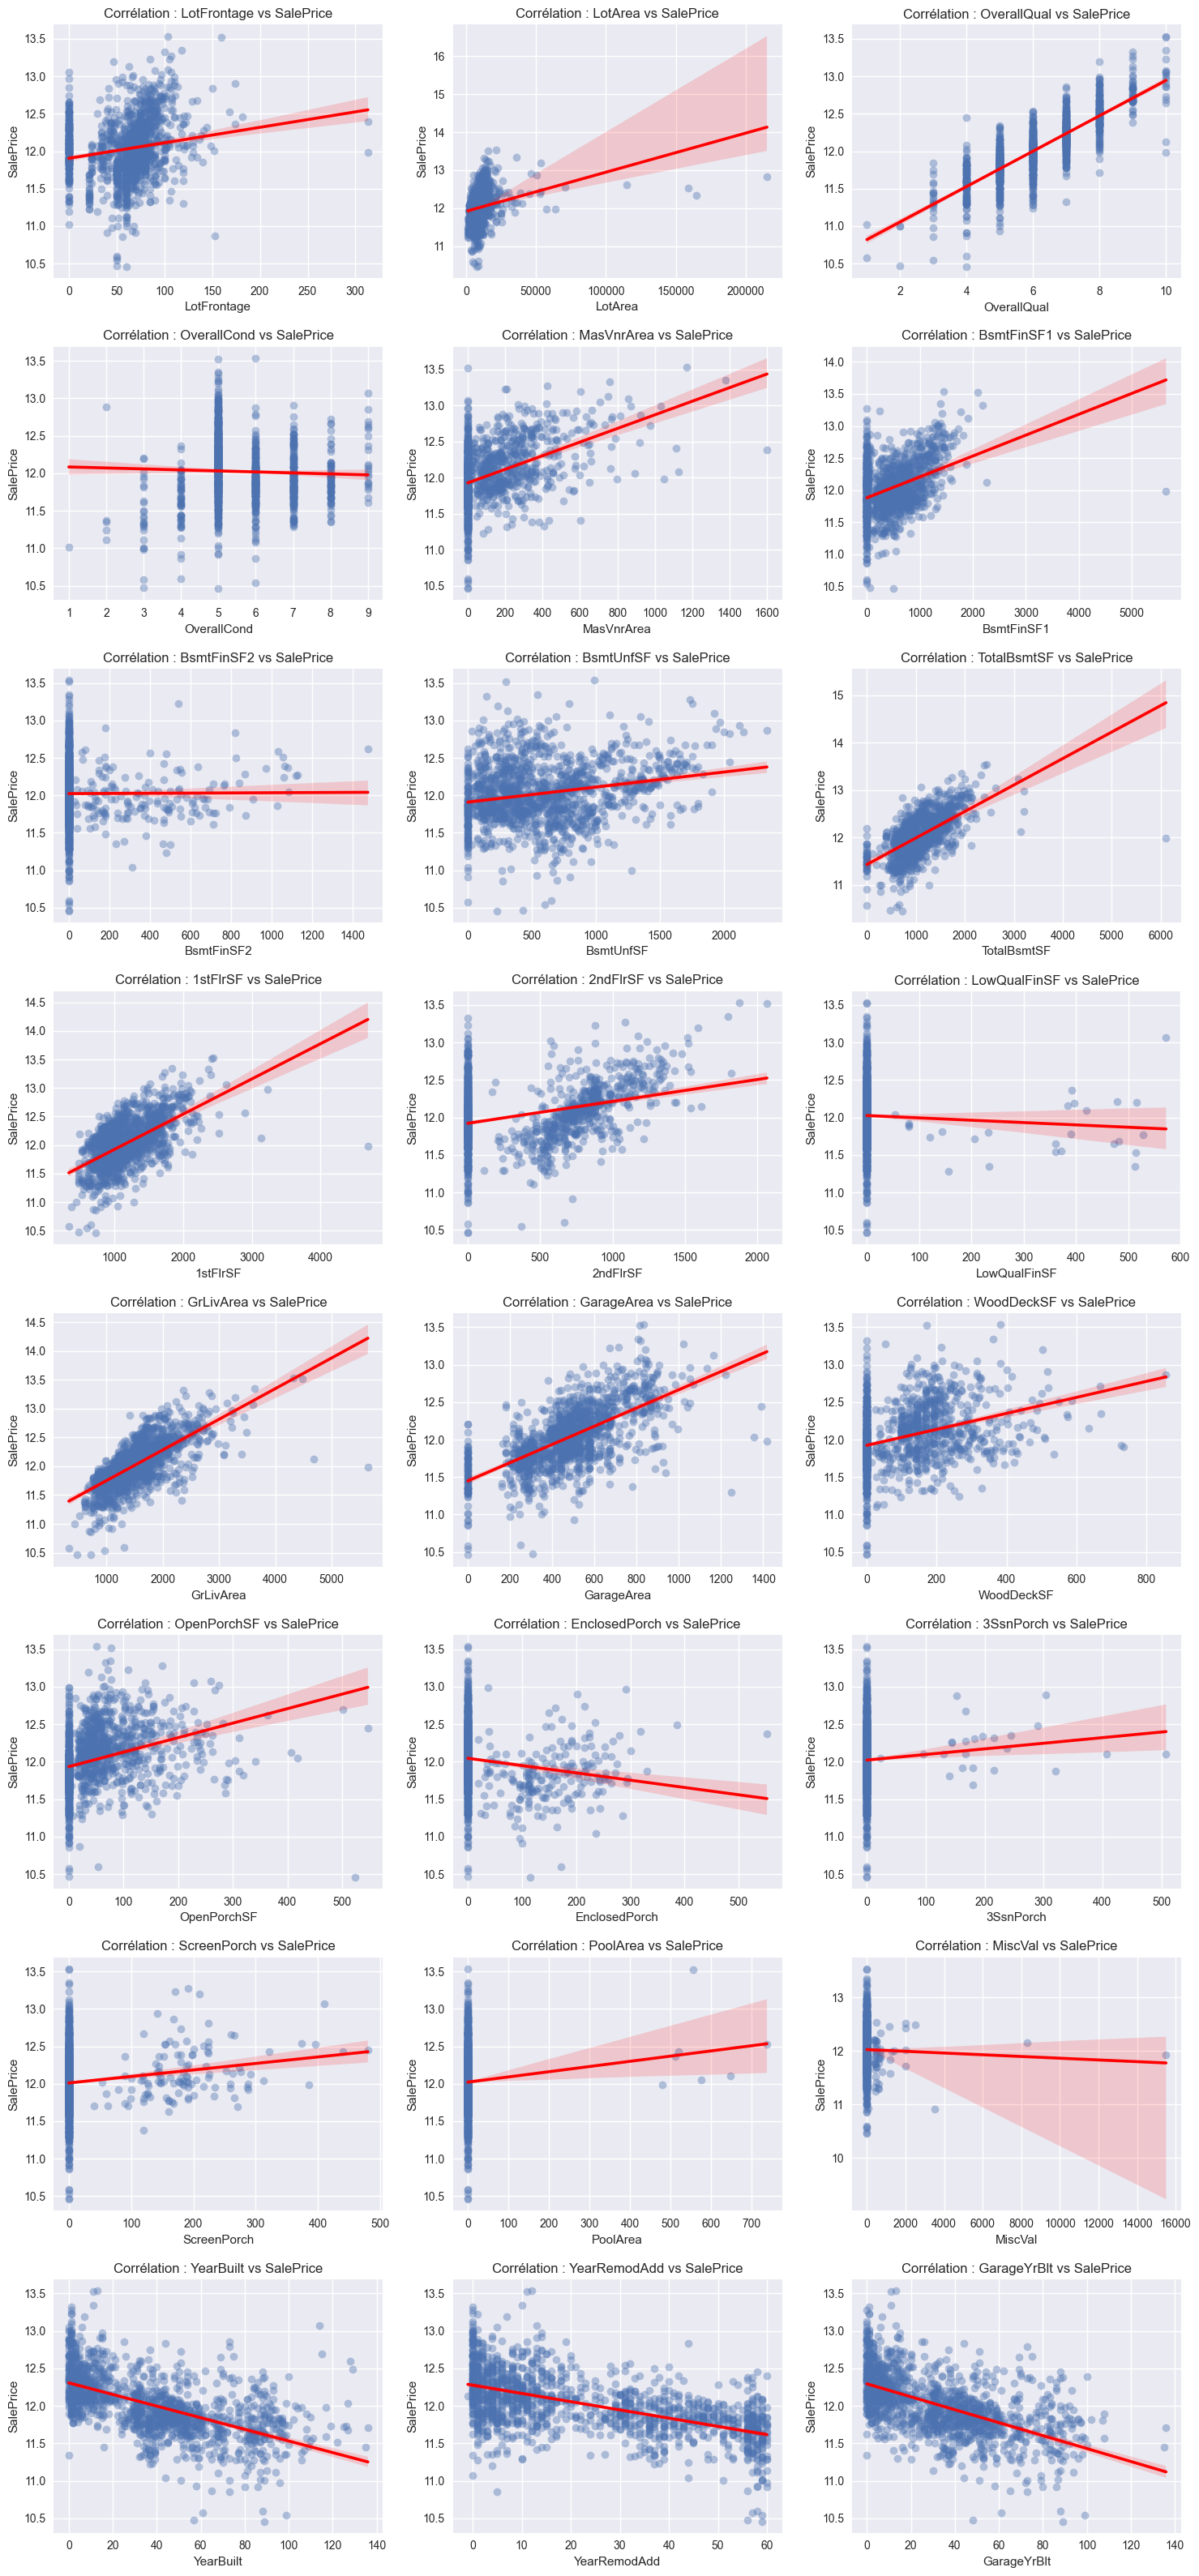

In [144]:
scatter_plots_grid(target, train_clean, numeric)


Les 24 graphiques ci-dessus illustrent les relations entre différentes variables numériques et le prix de vente (SalePrice, transformé en log). Ces visualisations nous permettent d’évaluer rapidement quelles variables ont un impact significatif sur le prix, et lesquelles peuvent être écartées de notre modélisation.

Variables avec forte corrélation (relation linéaire claire et montante) :
OverallQual, GrLivArea, TotalBsmtSF, 1stFlrSF, GarageArea
-> Ces variables montrent une tendance nette : à mesure que leur valeur augmente, le prix de vente augmente aussi. Ce sont des prédicteurs solides à retenir dans notre modèle.

Variables à corrélation modérée :
LotArea, MasVnrArea, WoodDeckSF, OpenPorchSF, ScreenPorch, PoolArea
-> Bien que la tendance soit moins marquée, ces variables peuvent ajouter de la valeur explicative, notamment lorsqu’elles sont combinées avec d’autres. Par exemple, une piscine ou une terrasse peut contribuer à une estimation plus fine dans des cas spécifiques.

Variables avec peu ou pas de lien visible :
LotFrontage, OverallCond, BsmtUnfSF, BsmtFinSF2, 2ndFlrSF, GarageYrBlt, YearBuilt, YearRemodAdd
-> Ces variables montrent une dispersion importante ou une relation presque horizontale avec SalePrice. Leur contribution semble limitée ou confuse, et elles pourraient être exclues du modèle ou retravaillées (par ex. encodage ou regroupement).

Variables sans intérêt voire contre-productives :
LowQualFinSF, EnclosedPorch, 3SsnPorch, MiscVal
-> Ces variables présentent peu de valeurs non nulles et n’apportent aucun signal clair sur le prix. Elles peuvent être considérées comme non pertinentes pour la prédiction.

### Analyse des variables catégorielles

Pour les variables catégorielles, nous ne pouvons pas effectuer de corrélation pour des raisons évidentes : ces variables ne sont pas numériques et ne possèdent pas d’ordre ou de distance mesurable entre leurs modalités. Nous devons donc effectuer une ANOVA, qui est la contrepartie statistique lorsque l’on souhaite analyser l’effet d’une variable catégorielle sur une variable numérique.
Cela nous permet de savoir si les différentes modalités d’une variable ont un impact significatif sur la variation des prix de vente.

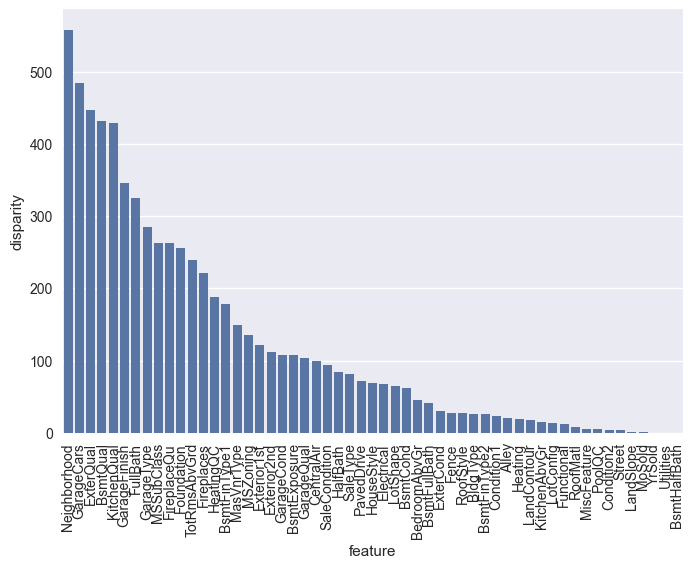

In [145]:
def anova(y, X, features):
    
    anova = pd.DataFrame()
    anova['feature'] = features
    pvals = []
    
    for f in features:
        
        samples = []
        
        for cls in X[f].unique():
            
            s = y[X[f] == cls].values
            samples.append(s)
            
        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)
        
    anova['pval'] = pvals
    anova = anova.sort_values('pval')
    
    anova['disparity'] = np.log(1. / anova['pval'].values)

    sns.barplot(data = anova, x = 'feature', y = 'disparity')
    x = plt.xticks(rotation=90)
    
    return anova

anova = anova(target, train_clean, categorical)

Ce graphique issu de l’ANOVA permet d’identifier quelles variables catégorielles différencient le plus les prix de vente selon leurs modalités. Par exemple, Neighborhood, ExterQual ou KitchenQual montrent une forte disparité entre groupes, ce qui indique qu’elles ont un impact plus marqué que d’autres variables comme Street ou BsmtHalfBath.
Cependant, une forte disparité ne signifie pas forcément une grande influence directe sur SalePrice, mais plutôt que la variable permet de mieux séparer les niveaux de prix entre ses catégories.

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def box_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        sns.boxplot(x=X[f], y=y, ax=axes[i])
        axes[i].set_title(f'Box plot {f} vs {y.name}')
        axes[i].tick_params(axis='x', rotation=90)

    # Supprimer les axes inutilisés s’il y a plus de cases que de variables
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()


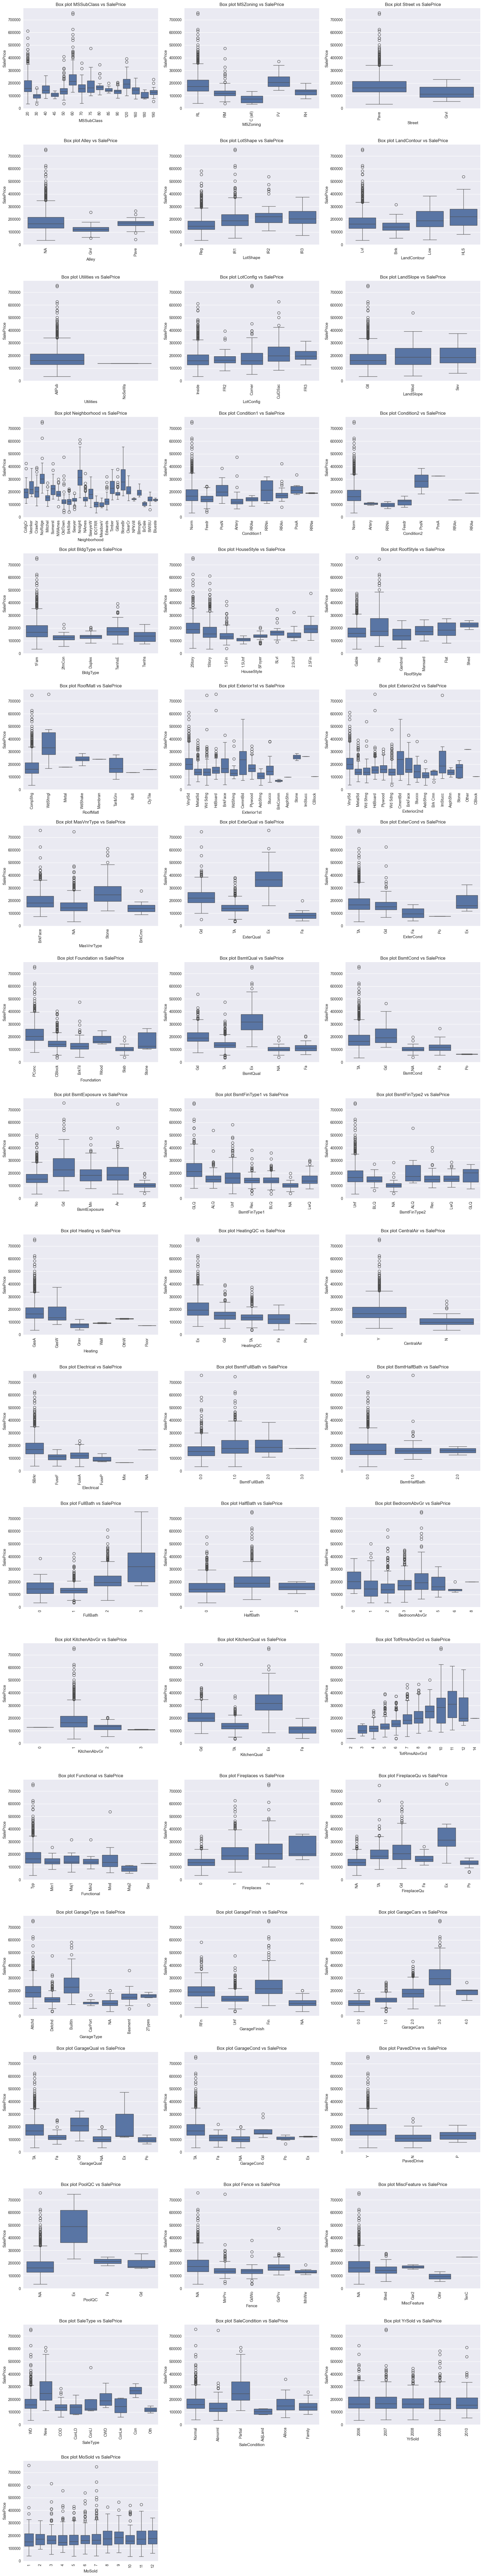

In [147]:
box_plots_grid(train_clean['SalePrice'], train_clean, categorical)


Les 55 boxplots ci-dessus montrent la relation entre les différentes variables catégorielles (y compris certaines variables numériques discrètes traitées comme catégorielles) et le prix de vente (SalePrice).
Ces visualisations permettent d’évaluer quelles caractéristiques ont un impact réel sur la valorisation d’un bien, et lesquelles peuvent être écartées de la modélisation.

Variables catégorielles avec forte influence sur le prix :
Neighborhood, ExterQual, KitchenQual, BsmtQual, GarageFinish, FireplaceQu, GarageType, HouseStyle, SaleCondition, GarageCars, FullBath, MSSubClass
-> Ces variables présentent des écarts nets de médianes selon les modalités. Elles capturent des éléments structurants du bien (emplacement, qualité perçue, disposition, équipements) et sont des leviers de prix évidents.
Elles devront absolument être conservées et bien encodées dans le modèle.

Variables à influence modérée :
MSZoning, BldgType, Foundation, Exterior1st, Exterior2nd, RoofStyle, Functional, Fireplaces, MasVnrType, HeatingQC, TotRmsAbvGrd, HalfBath, BedroomAbvGr, SaleType
-> Ces variables montrent une certaine variation de prix entre groupes, mais avec des dispersions ou recoupements. Elles restent intéressantes et pourront compléter les variables principales, en interaction ou agrégées.

Variables à faible effet ou à surveiller :
CentralAir, Electrical, Condition1, Condition2, BsmtFinType1, BsmtExposure, LotConfig, KitchenAbvGr, GarageQual, GarageCond, PavedDrive, RoofMatl, BsmtFullBath, Fireplaces, LotShape, LandContour
-> Leurs boxplots indiquent peu de différence claire entre catégories, ou des modalités dominantes. Leur effet semble faible ou indirect, elles seront à tester au cas par cas.

Variables non informatives ou déséquilibrées :
Utilities, Street, Alley, PoolQC, Fence, MiscFeature, LandSlope, BsmtHalfBath, MoSold, YrSold
-> Ces variables sont soit massivement déséquilibrées (ex. : quasi toutes les maisons ont AllPub pour Utilities), soit trop rares pour être exploitables (piscines, allées pavées), ou sans impact clair sur le prix.
Elles peuvent être supprimées ou binarisées si besoin, mais ne seront pas prioritaires dans notre modélisation.



# Baseline Model Engineering

Créons maintenant notre modèle. Nous commencerons par un modèle de base simple, puis nous augmenterons la complexité.

## 2.1 Ingénierie des données de base

Afin d'effectuer une analyse de régression, nous devons préparer un peu plus notre ensemble de données. En particulier, nous allons transformer les variables catégorielles en variables numériques.

Une astuce intéressante dans notre scénario de régression consiste à remplacer la catégorie par la **moyenne** de notre variable cible pour cette catégorie. Cette transformation crée alors une corrélation naturelle entre notre nouvelle variable et notre variable cible. Une autre approche (factice) consisterait à utiliser simplement pd.getDummies(), mais ce n'est pas si efficace et trompeur à mon avis.



In [148]:
def encode_with_mean(data, target, features):
    
    data_preprocess = data.copy()
    
    for f in features: 
        
        # create a temporary dataframe for our workload
        frame = pd.DataFrame()
        frame[f] = data[f].copy()
        frame[target.name] = target.copy()
        
        # create the mapping table
        mapping = pd.DataFrame()
        mapping['val'] = data[f].unique()
        mapping.index = mapping.val
        
        # compute the mean of our target variable for each category
        mapping['mean'] = frame[[f, target.name]].groupby(f).mean()[target.name]
        
        # if a category has NA, we shall simply put the mean value
        mapping['mean'] = mapping['mean'].fillna(target.mean())

        # we replace the feature with the means in the mapping table
        data_preprocess[f] = pd.merge(data_preprocess, mapping, left_on = f, right_index = True)['mean'].copy()
        
    return data_preprocess

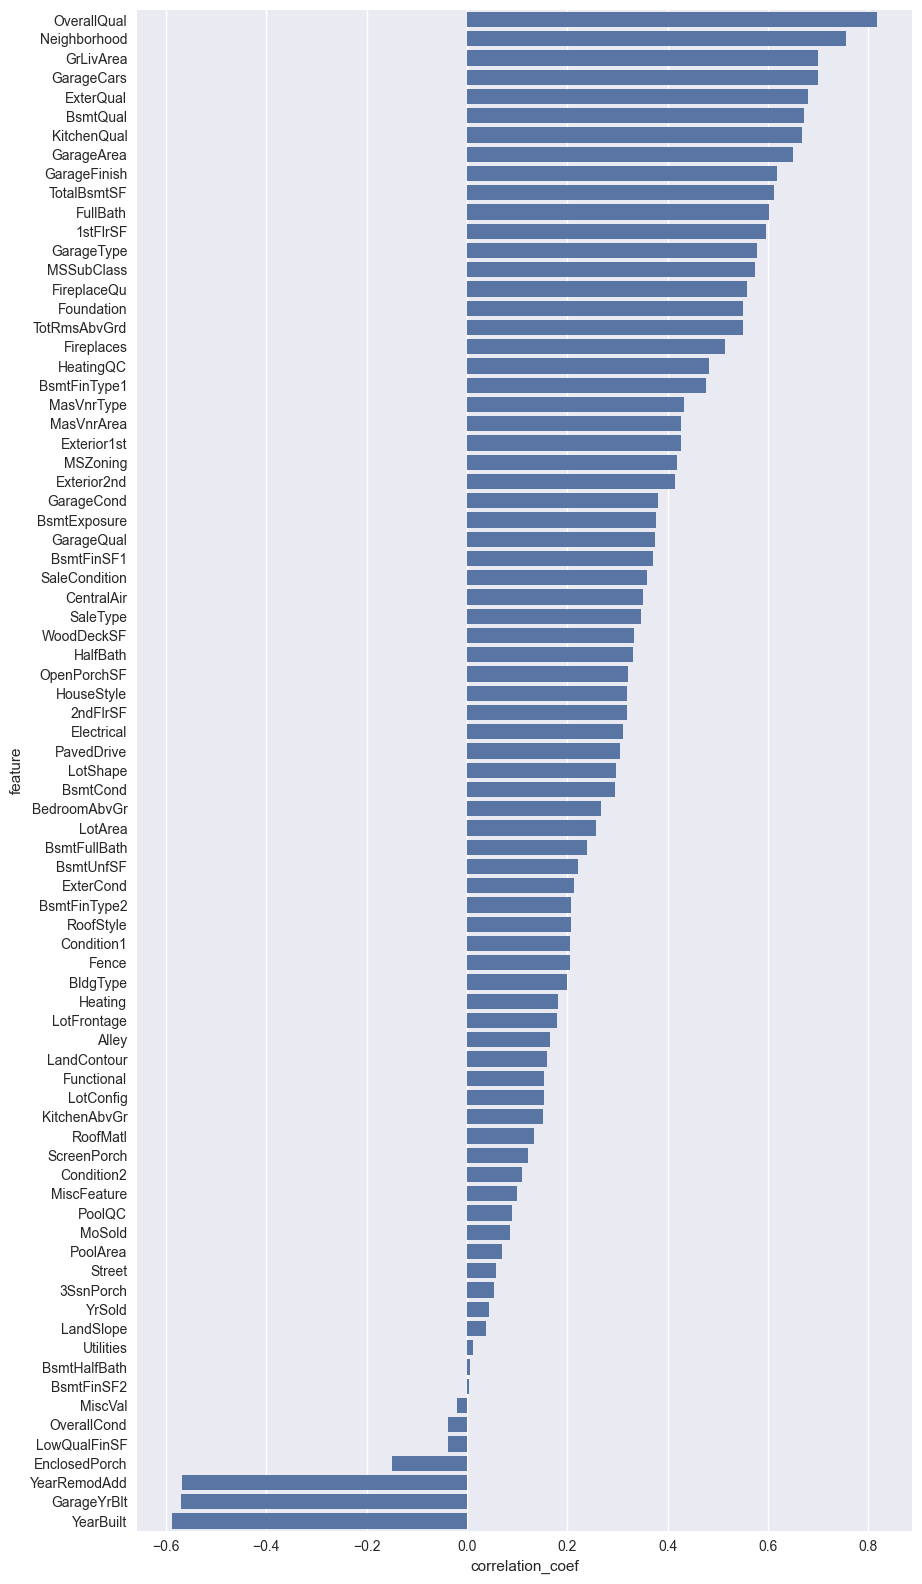

In [149]:
data_preprocess = encode_with_mean(data_clean, target, categorical)

# Split of the clean dataset into train & validation
train_preprocess = data_preprocess[data_preprocess.index.isin(train_raw.index)]
validation_preprocess = data_preprocess[data_preprocess.index.isin(validation_raw.index)]

cor = correlation(target, train_preprocess, numeric + categorical)

Nous constatons que de nombreuses caractéristiques sont en corrélation avec le **logarithme du prix de vente**, ce qui est bon pour notre cas d'utilisation. Jetons un coup d'œil à la corrélation interne entre les variables. Nous limitons notre visualisation aux caractéristiques qui ont une corrélation modérée ou supérieure (c'est-à-dire un coefficient de corrélation supérieur à 0,5 en valeur absolue).



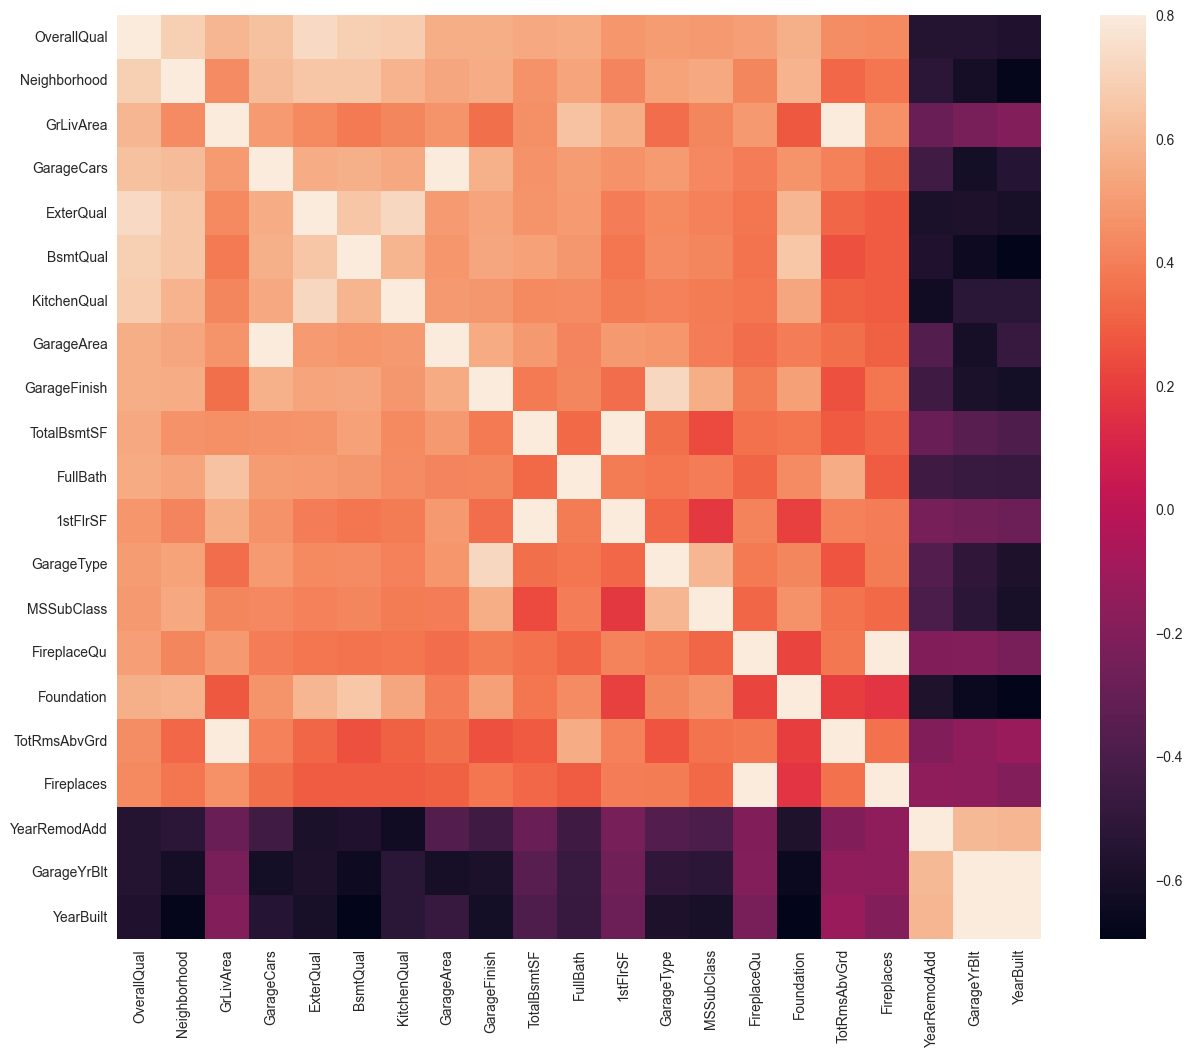

In [150]:
cols = cor[abs(cor['correlation_coef']) > 0.5]['feature'].tolist()
correlation_matrix = train_preprocess[cols].corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(correlation_matrix, vmax=.8, square=True)
plt.show()

Il existe de nombreuses corrélations internes. Nous devrons donc sélectionner soigneusement les variables afin d'éviter la multicolinéarité.

## 2.2 Baseline Model - Linear Regression

Nous commençons par le modèle le plus basique, à savoir la régression linéaire. D'après notre analyse et notre compréhension du marché du logement, il est intéressant de considérer les variables suivantes :

- OverallQual
- Neighborhood
- GrLivArea
- TotalBsmtSF
- YearBuilt

C'est tout à fait logique, car ce sont les principales variables que l'on recherche pour une maison, à savoir la qualité générale du bien, le quartier, la surface habitable et l'année de construction de la maison. Le sous-sol est particulièrement important à Ames, car il s'agit d'une région où le risque de tornade est élevé.

In [151]:
base = ['OverallQual', 'Neighborhood', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']

X = train_preprocess[base]
X_val = validation_preprocess[base]

y = target.copy()

To fit the linear regression, we use the library StatsModels which comes with very handy functions for model understanding.

In [152]:
import statsmodels.api as sm

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1367.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        17:06:38   Log-Likelihood:                 539.40
No. Observations:                1460   AIC:                            -1067.
Df Residuals:                    1454   BIC:                            -1035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8392      0.271     25.244   

### Hypothèses de régression linéaire

Si nous voulons utiliser une régression linéaire, nous devons vérifier certaines hypothèses, à savoir :

- Linéarité du lien entre les variables indépendantes et la variable dépendante.
- Les résidus sont normalement distribués autour de 0
- Homoscédasticité
- Les résidus sont exempts de structure
- Les résidus sont exempts de valeurs aberrantes

Voici un code que j'ai trouvé sur https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/ et qui fait cela très bien.
*** Traduit avec www.DeepL.com/Translator (version gratuite) ***



In [153]:
from statsmodels.graphics.gofplots import ProbPlot
plt.rc('font', size=14)
plt.rc('figure', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=18)

def graph(formula, x_range, label=None):
    """
    Helper function for plotting cook's distance lines
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')


def diagnostic_plots(X, y, model_fit=None):
    """
    Function to reproduce the 4 base plots of an OLS model in R.

    ---
    Inputs:

    X: A numpy array or pandas dataframe of the features to use in building the linear regression model
    y: A numpy array or pandas series/dataframe of the target variable of the linear regression model

    model_fit [optional]: a statsmodel.api.OLS model after regressing y on X. If not provided, will be
                        generated from X, y
    """

    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # create dataframe from X, y for easier plot handling
    dataframe = pd.concat([X, y], axis=1)
    
    # model values
    model_fitted_y = model_fit.fittedvalues
    # model residuals
    model_residuals = model_fit.resid
    # normalized residuals
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    # absolute squared normalized residuals
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    # absolute residuals
    model_abs_resid = np.abs(model_residuals)
    # leverage, from statsmodels internals
    model_leverage = model_fit.get_influence().hat_matrix_diag
    # cook's distance, from statsmodels internals
    model_cooks = model_fit.get_influence().cooks_distance[0]
    
    plot_lm_1 = plt.figure()
    plot_lm_1.axes[0] = sns.residplot(x = model_fitted_y, y = dataframe.columns[-1], data = dataframe,
                                      lowess=True,
                                      scatter_kws={'alpha': 0.5},
                                      line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    
    plot_lm_1.axes[0].set_title('Residuals vs Fitted')
    plot_lm_1.axes[0].set_xlabel('Fitted values')
    plot_lm_1.axes[0].set_ylabel('Residuals');
    
    # annotations
    abs_resid = model_abs_resid.sort_values(ascending=False)
    abs_resid_top_3 = abs_resid[:3]
    for i in abs_resid_top_3.index:
        plot_lm_1.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_residuals[i]));
        
    QQ = ProbPlot(model_norm_residuals)
    plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    plot_lm_2.axes[0].set_title('Normal Q-Q')
    plot_lm_2.axes[0].set_xlabel('Theoretical Quantiles')
    plot_lm_2.axes[0].set_ylabel('Standardized Residuals');
    
    # annotations
    abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
    abs_norm_resid_top_3 = abs_norm_resid[:3]
    for r, i in enumerate(abs_norm_resid_top_3):
        plot_lm_2.axes[0].annotate(i,
                                   xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                       model_norm_residuals[i]));
    
    plot_lm_3 = plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
    sns.regplot(x = model_fitted_y, y = model_norm_residuals_abs_sqrt,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_3.axes[0].set_title('Scale-Location')
    plot_lm_3.axes[0].set_xlabel('Fitted values')
    plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');
    
    # annotations
    abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
    abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
    for i in abs_norm_resid_top_3:
        plot_lm_3.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_norm_residuals_abs_sqrt[i]));
    
    plot_lm_4 = plt.figure();
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
    sns.regplot(x = model_leverage, y = model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_4.axes[0].set_xlim(0, max(model_leverage)+0.01)
    plot_lm_4.axes[0].set_ylim(-3, 5)
    plot_lm_4.axes[0].set_title('Residuals vs Leverage')
    plot_lm_4.axes[0].set_xlabel('Leverage')
    plot_lm_4.axes[0].set_ylabel('Standardized Residuals');
    
    # annotations
    leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
    for i in leverage_top_3:
        plot_lm_4.axes[0].annotate(i,
                                   xy=(model_leverage[i],
                                       model_norm_residuals[i]));
        
    p = len(model_fit.params) # number of model parameters
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50),
          'Cook\'s distance') # 0.5 line
    graph(lambda x: np.sqrt((1 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50)) # 1 line
    plot_lm_4.legend(loc='upper right');

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
C:\Users\davgi\AppData\Local\Temp\ipykernel_23260\2222118861.py:92: SyntaxWarning: invalid escape sequence '\s'
  plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');


c:\Users\davgi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


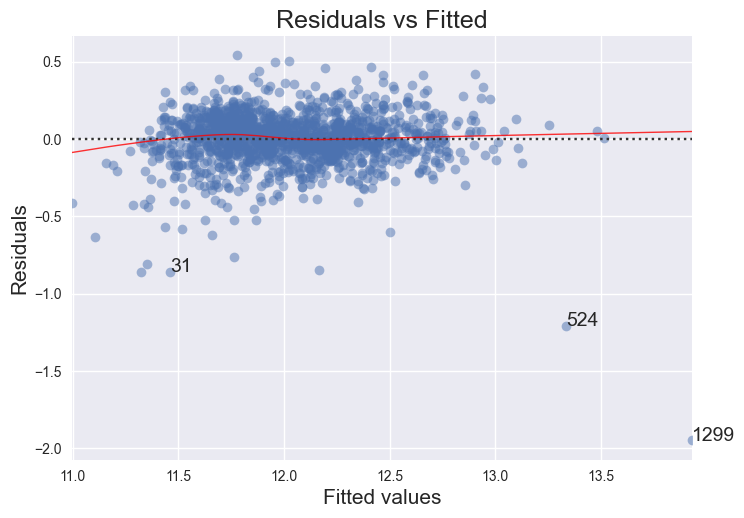

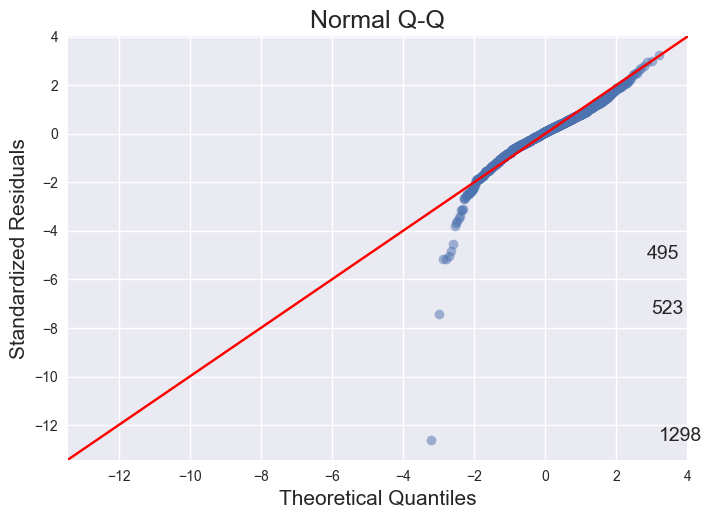

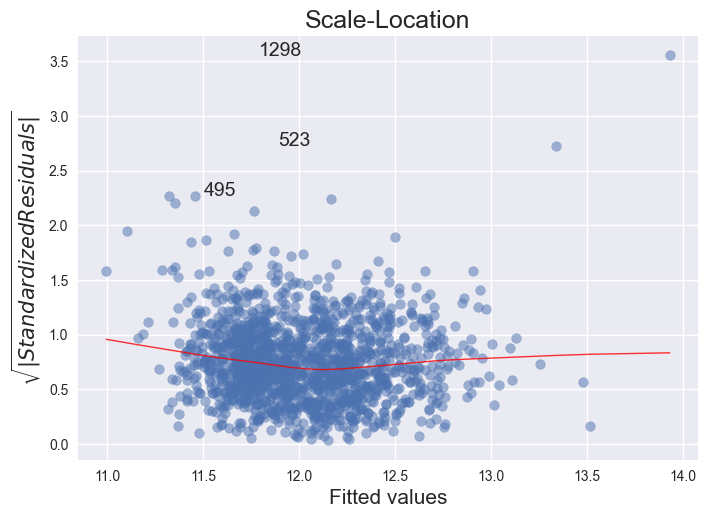

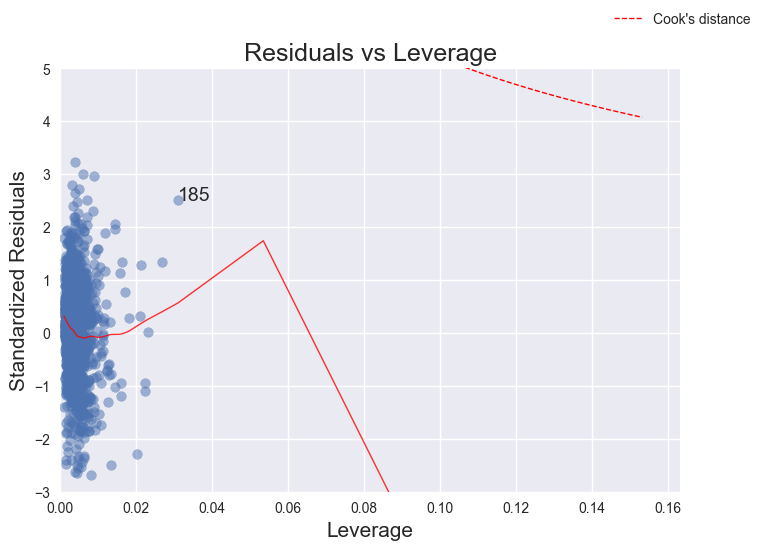

In [154]:
diagnostic_plots(sm.add_constant(X), y)

#### Residuals Analysis

The residuals look free of structure and seems normally distributed around 0. However, we observe some outliers in the residuals. Let's have a look at these data.

In [155]:
print(X[base].iloc[[523, 1298]])

      OverallQual  Neighborhood  GrLivArea  TotalBsmtSF  YearBuilt
Id                                                                
524            10     11.712321       4676       3138.0          0
1299           10     11.712321       5642       6110.0          0


Dans la documentation (http://jse.amstat.org/v19n3/decock/DataDocumentation.txt), on peut lire

NOTES SPÉCIALES :
Il y a 5 observations qu'un instructeur peut souhaiter supprimer de l'ensemble de données avant de le donner aux étudiants (un graphique du PRIX DE VENTE en fonction de la ZONE DE VIE GR les indiquera rapidement). Trois d'entre elles sont de véritables valeurs aberrantes (des ventes partielles qui ne représentent probablement pas les valeurs réelles du marché) et deux d'entre elles sont simplement des ventes inhabituelles (de très grandes maisons dont le prix est relativement approprié). Je recommanderais d'éliminer toutes les maisons de plus de 4000 pieds carrés de l'ensemble de données (ce qui élimine ces 5 observations inhabituelles) avant de l'assigner aux étudiants.

Examinons donc les valeurs aberrantes, en particulier dans la colonne **GrLivArea**.



In [156]:
def remove_outliers(data, target, feature):
    
    data_preprocess = data.copy()
    data_preprocess[target.name] = target.copy()
    
    #Compute interquartile range
    q1 = data_preprocess[feature].quantile(0.25)
    q3 = data_preprocess[feature].quantile(0.75)
    
    iqr = q3-q1 
    
    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr
    
    data_preprocess = data_preprocess.loc[(data_preprocess[feature] > fence_low) & (data_preprocess[feature] < fence_high)]
    
    return data_preprocess[data.columns], data_preprocess[target.name]

Nous allons maintenant exécuter le même code que ci-dessus, sans les valeurs aberrantes

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1522.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        17:06:40   Log-Likelihood:                 659.93
No. Observations:                1429   AIC:                            -1308.
Df Residuals:                    1423   BIC:                            -1276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.7556      0.257     30.195   

c:\Users\davgi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


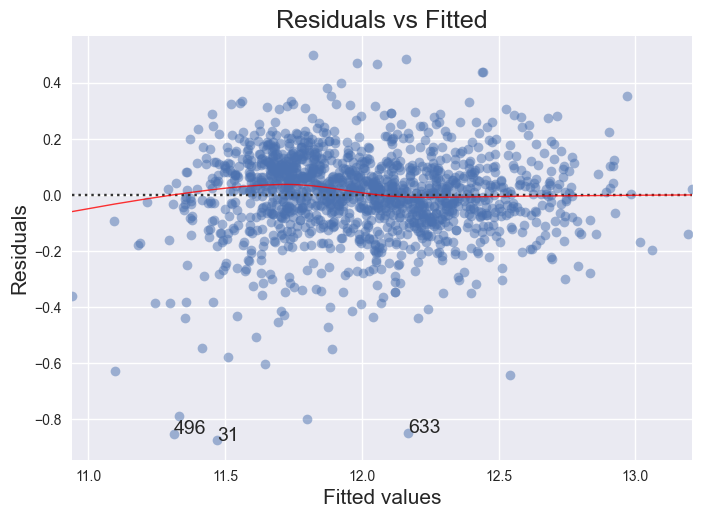

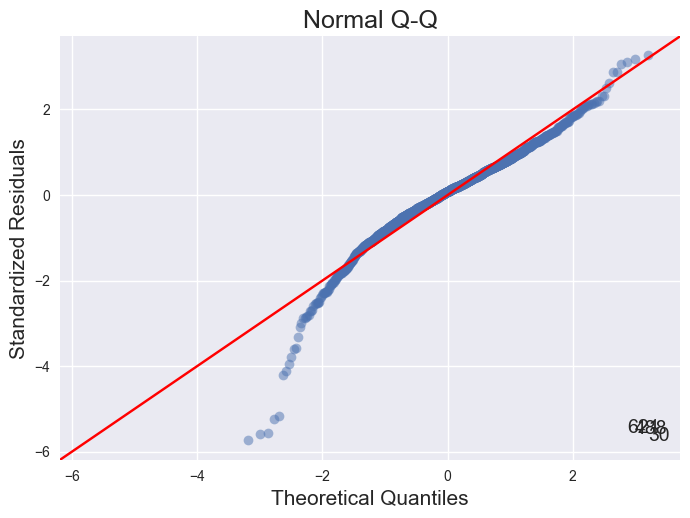

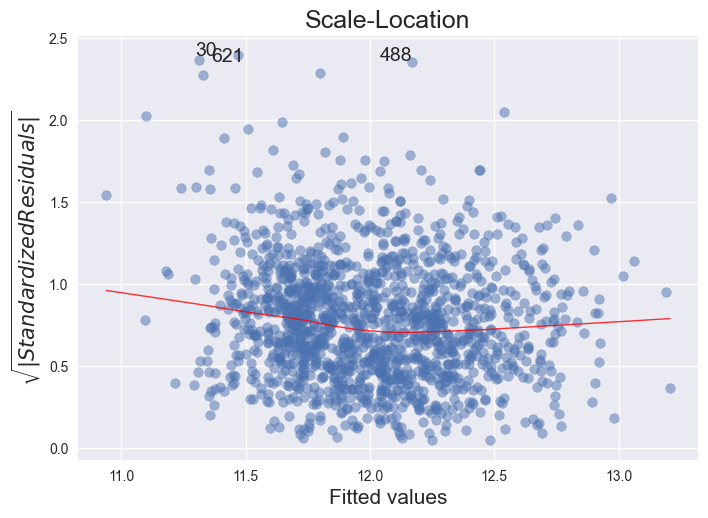

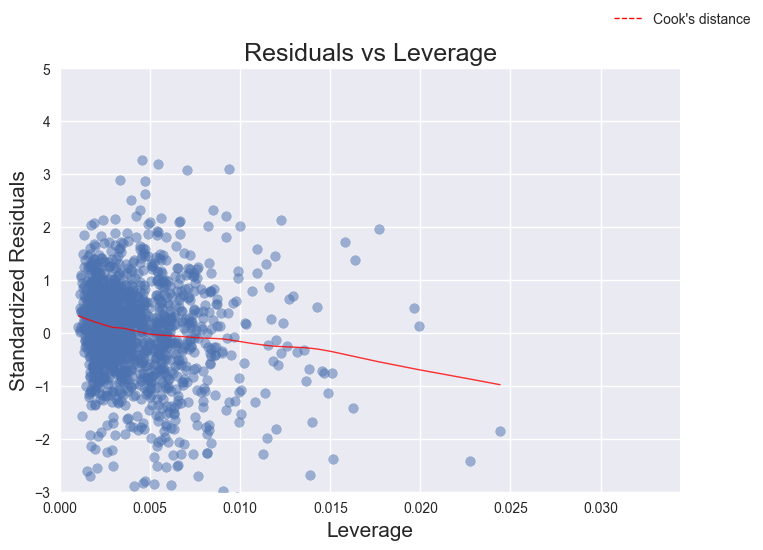

In [157]:
X, y = remove_outliers(X, y, feature = 'GrLivArea')

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

diagnostic_plots(sm.add_constant(X), y)

Ok, c'est beaucoup mieux. Évaluons maintenant notre modèle de base et voyons dans quelle mesure il sera performant sur Kaggle. Pour ce faire, nous utiliserons la méthode **predict**.

In [158]:
y_pred = res.predict(sm.add_constant(X))
print(y_pred.head())

Id
1    12.214534
2    12.081588
3    12.244451
4    12.046219
5    12.620316
dtype: float64


Nous allons visualiser le diagramme de dispersion dans lequel nous comparons la valeur réelle aux valeurs prédites.

In [159]:
def plot_prediction(actual, predicted) :
    
    data = pd.concat([actual, predicted], keys = ['actual', 'predicted'], axis = 1)

    plt.title('Actual vs Predicted')
    sns.regplot(x = 'actual', y = 'predicted', data = data)
    plt.show()

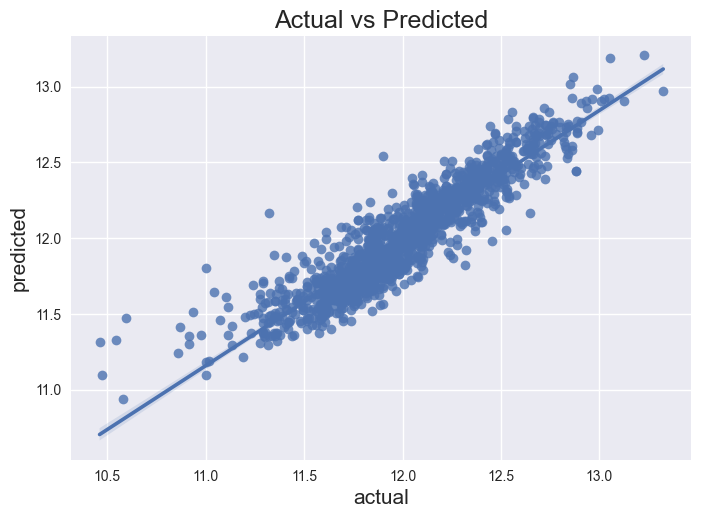

In [160]:
plot_prediction(y, y_pred)

Cela semble fonctionner correctement. Attention au surajustement ici, puisque nous avons prédit et ajusté sur le même ensemble de données. Pour des modèles plus complexes, cela peut être un problème sérieux.

In [161]:
import numpy as np
from sklearn.metrics import mean_squared_log_error

def rmsle(actual, predicted):
    return np.sqrt(mean_squared_log_error(actual, predicted))


In [162]:
print('Root Mean Square Log Error (RMSLE) :', rmsle(y, y_pred))

Root Mean Square Log Error (RMSLE) : 0.011897571840070703


## 2.3 Baseline Model submission on Kaggle

We use the **predict** method on the validation dataset

In [163]:
y_val = res.predict(sm.add_constant(X_val))

print(y_val.head())

Id
1461    11.663271
1462    11.946171
1463    12.025787
1464    12.101195
1465    12.341289
dtype: float64


We write now our predictions in the _baseline.csv_ file and don't forget to use the inverse function of **np.log1p**, namely **np.expm1**.

In [164]:
submission = pd.DataFrame()
submission['Id'] = y_val.index
submission['SalePrice'] = np.expm1(y_val.values)

submission.to_csv('Data/baseline.csv', index = False)

OSError: Cannot save file into a non-existent directory: 'Data'

<img src="Img/baseline.jpg" width=800 />